In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [2]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


In [3]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

C:\Users\Matth\AppData\Local\Temp\ipykernel_107628\3799972245.py:16: RuntimeWarning: invalid value encountered in sqrt
  view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time


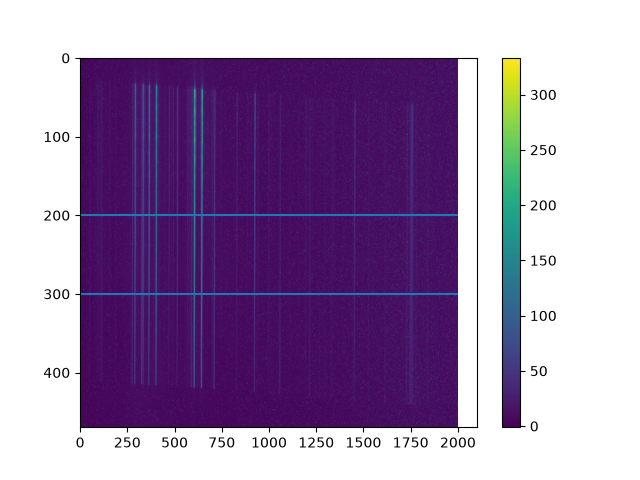

In [4]:
linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Xe"], maxAmp=2000000, minWav=10000, maxWav=15000)
#lines = Util.loadLineList("tmpLines.dat")

imagePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\step0\\drive-download-20260309T151050Z-3-001\\20250123.rimas.0060.YJ.fits"
spec2D = fits.open(imagePath)[0].data

spec2D[np.isnan(spec2D)]=-1
spec2D = Spec2D.cropImage(spec2D, 1740, 1000, 470, 2000)
#Spec2D.flipX(spec2D)

minY = 200
maxY = 300

fig, ax = plt.subplots()
view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time
view[np.isnan(view)]=-1
img = ax.imshow(view, vmin=np.min(view), vmax=np.max(view)) 
fig.colorbar(img)
ax.hlines([minY, maxY], 0, 2000)
ax.set_aspect("auto")

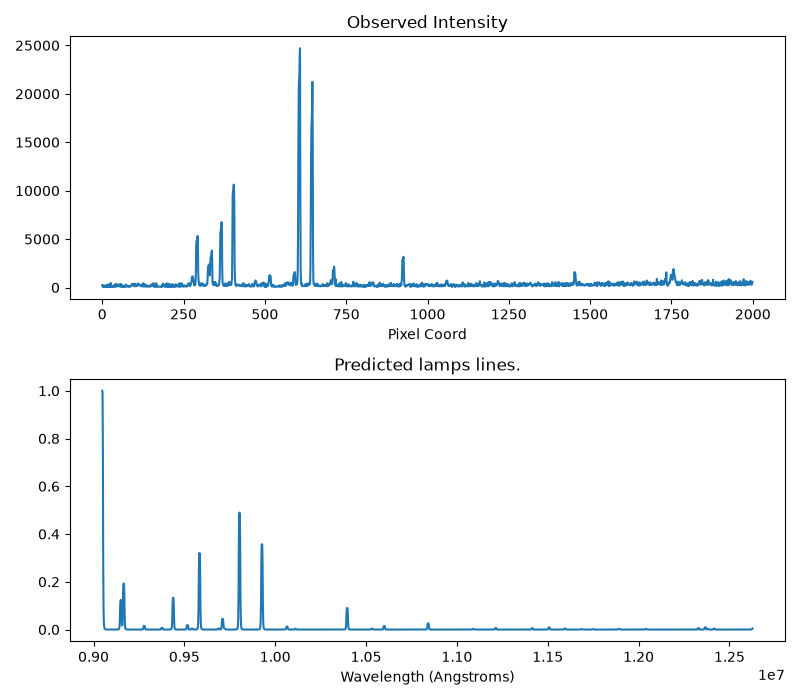

In [ ]:
spec = Spec1D.convert2Dto1D(spec2D, minY, maxY)
continuum = Spec1D.continuum(spec, thresh=1, debug=False)
contSub = spec - continuum(np.arange(0, len(spec)))

NISTLines = Util.loadNISTData("YJ\\NIST_lines.dat", minWav = 10000, maxWav=20000, minAmp = 1)

fig, ax = plt.subplots(2,1, figsize=(8,7))
ax[0].plot(spec)
ax[0].set_xlabel("Pixel Coord")
ax[0].set_title("Observed Intensity")
w, a = 9600, 0.3
XeLines = Util.simpleLineListToPypeIt("YJ/arc.Xe.YJ_identified_lines.curvefit_peaks.csv", ion="Xe", conversionFactorToAngstroms=10000, writePath="Xe_RIMAS_YJ_lines.dat")
ArLines = Util.simpleLineListToPypeIt("YJ/arc.Ar.YJ_identified_lines.curvefit_peaks.csv", ion="Ar", conversionFactorToAngstroms=10000, writePath="Ar_RIMAS_YJ_lines.dat")
HgLines = Util.simpleLineListToPypeIt("YJ/arc.Hg.YJ_identified_lines.curvefit_peaks.csv", ion="Hg", conversionFactorToAngstroms=10000, writePath="Hg_RIMAS_YJ_lines.dat")
KrLines = Util.simpleLineListToPypeIt("YJ/arc.Kr.YJ_identified_lines.curvefit_peaks.csv", ion="Kr", conversionFactorToAngstroms=10000, writePath="Kr_RIMAS_YJ_lines.dat")
XeModel = Spec1D.calcModel(XeLines, 2000, XeLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
ArModel = Spec1D.calcModel(ArLines, 2000, ArLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
HgModel = Spec1D.calcModel(HgLines, 2000, HgLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
KrModel = Spec1D.calcModel(KrLines, 2000, KrLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
model = XeModel + KrModel + HgModel
ax[1].plot(np.linspace(XeLines[0][0], XeLines[-1][0], 2000)*1000, model/np.max(model))
ax[1].set_xlabel("Wavelength (Angstroms)")
ax[1].set_title("Predicted lamps lines.")
fig.tight_layout()

In [10]:
#Takes a long time to run, because there are many lines in the line list
w, a = Spec1D.calcLinearFit(contSub, lines, 9000, 10000, 0.1, 0.4, resW=250, resS=250)
print(w, a)

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('<U3'), dtype('float64')) -> None